# Topic Modeling Analysis — Section 5.4

วิเคราะห์ผลลัพธ์จาก Topic Modeling Pipeline (Attempt 4) ครอบคลุม:
- **5.4.2** Theme Stability — stable_score ของแต่ละ theme ข้าม 38 รัฐธรรมนูญ
- **5.4.3** Theme Dynamics — trend_delta เปรียบเทียบยุคต้น vs ยุคปลาย
- **5.4.4** Co-occurrence — theme คู่ที่ปรากฏร่วมกันในมาตราเดียวกันมากที่สุด

**Input files** (จาก `../03_data_preparation/04_topic_mod/attempt4/`):
- `section_theme_scores.csv`
- `theme_stable_summary.csv`
- `theme_dynamic_summary.csv`
- `theme_timeline_mass.csv`
- `conflict_edges.csv`

## Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

# Thai font
font_path = '../static/font/LINESeedSansTH_Rg.ttf'
fm.fontManager.addfont(font_path)
font_prop = fm.FontProperties(fname=font_path)
plt.rcParams['font.family'] = font_prop.get_name()
plt.rcParams['axes.unicode_minus'] = False
print(f"Font loaded: {font_prop.get_name()}")

Font loaded: LINE Seed Sans TH


In [3]:
DATA_DIR = Path('../03_data_preparation/04_topic_mod/attempt4')

scores_df    = pd.read_csv(DATA_DIR / 'section_theme_scores.csv')
stable_df    = pd.read_csv(DATA_DIR / 'theme_stable_summary.csv')
dynamic_df   = pd.read_csv(DATA_DIR / 'theme_dynamic_summary.csv')
timeline_df  = pd.read_csv(DATA_DIR / 'theme_timeline_mass.csv')
edges_df     = pd.read_csv(DATA_DIR / 'conflict_edges.csv')

print('section_theme_scores :', scores_df.shape)
print('theme_stable_summary :', stable_df.shape)
print('theme_dynamic_summary:', dynamic_df.shape)
print('theme_timeline_mass  :', timeline_df.shape)
print('conflict_edges       :', edges_df.shape)

section_theme_scores : (5478, 7)
theme_stable_summary : (16, 6)
theme_dynamic_summary: (16, 7)
theme_timeline_mass  : (284, 3)
conflict_edges       : (49, 3)


---
## 5.4.2 Theme Stability

```
stable_score = 0.7 × coverage_ratio + 0.3 × avg_theme_score
```

แสดงตารางเรียงตาม stable_score จากมากไปน้อย และ bar chart เปรียบเทียบ coverage กับ stable_score

In [4]:
# ตาราง 15 — Theme Stability
stable_display = stable_df.copy()
stable_display['coverage'] = stable_display.apply(
    lambda r: f"{r['n_constitutions']}/38 ({r['coverage_ratio']*100:.1f}%)", axis=1
)
stable_display = stable_display.sort_values('stable_score', ascending=False)

table = stable_display[['theme', 'n_sections', 'coverage', 'stable_score']].copy()
table.columns = ['Theme', 'จำนวนมาตรา', 'รัฐธรรมนูญ (Coverage)', 'stable_score']
table['stable_score'] = table['stable_score'].round(3)
table = table.reset_index(drop=True)
table.index += 1
table

,Theme,จำนวนมาตรา,รัฐธรรมนูญ (Coverage),stable_score
1,บริหาร,730,38/38 (100.0%),0.839
2,สถาบันพระมหากษัตริย์,741,36/38 (94.7%),0.838
3,แนวนโยบายแห่งรัฐ,612,36/38 (94.7%),0.820
4,นิติบัญญัติ,1257,33/38 (86.8%),0.779
5,พรรคการเมืองและการเลือกตั้ง,428,28/38 (73.7%),0.628
6,สิทธิ-เสรีภาพ-หน้าที่,662,25/38 (65.8%),0.598
7,อื่น ๆ (emergent),19,16/38 (42.1%),0.595
8,ตุลาการ,427,22/38 (57.9%),0.567
9,ท้องถิ่น,178,15/38 (39.5%),0.406
10,จริยธรรมทางการเมือง,98,13/38 (34.2%),0.373


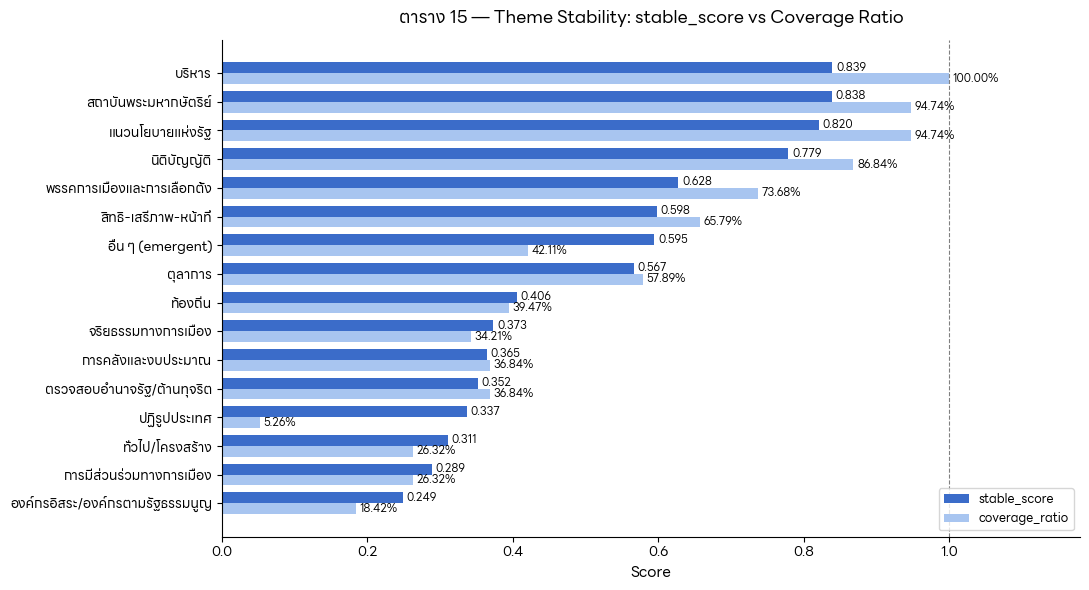

In [5]:
fig, ax = plt.subplots(figsize=(11, 6))

df_plot = stable_display.sort_values('stable_score')
themes = df_plot['theme']
y = np.arange(len(themes))
bar_h = 0.38

bars1 = ax.barh(y + bar_h/2, df_plot['stable_score'], bar_h,
                color='#3B6CC9', label='stable_score')
bars2 = ax.barh(y - bar_h/2, df_plot['coverage_ratio'], bar_h,
                color='#A8C5F0', label='coverage_ratio')

for bar in bars1:
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.3f}', va='center', fontsize=8)
for bar in bars2:
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.2%}', va='center', fontsize=8)

ax.set_yticks(y)
ax.set_yticklabels(themes, fontsize=10)
ax.set_xlabel('Score', fontsize=11)
ax.set_title('ตาราง 15 — Theme Stability: stable_score vs Coverage Ratio', fontsize=13, pad=12)
ax.set_xlim(0, 1.18)
ax.axvline(1.0, color='grey', linewidth=0.8, linestyle='--')
ax.legend(loc='lower right', fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
# plt.savefig('theme_stability_bar.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5.4.3 Theme Dynamics

```
trend_delta = last_ratio − first_ratio
```

ค่าบวก = theme เพิ่มขึ้นในรัฐธรรมนูญยุคหลัง | ค่าลบ = ลดลง

In [6]:
# ตาราง 16 — Theme Dynamics
dyn_display = dynamic_df.sort_values('trend_delta', ascending=False).copy()
dyn_display['first_ratio_pct'] = dyn_display['first_ratio'].map(lambda x: f'{x:.1%}')
dyn_display['last_ratio_pct']  = dyn_display['last_ratio'].map(lambda x: f'{x:.1%}')
dyn_display['trend_delta_fmt'] = dyn_display['trend_delta'].map(
    lambda x: f'+{x:.3f}' if x >= 0 else f'{x:.3f}'
)
dyn_display['ทิศทาง'] = dyn_display['trend_delta'].apply(
    lambda x: 'เพิ่มขึ้น ▲' if x > 0.005 else ('ลดลง ▼' if x < -0.005 else 'คงที่ →')
)

table2 = dyn_display[['theme', 'first_ratio_pct', 'last_ratio_pct', 'trend_delta_fmt', 'ทิศทาง']].copy()
table2.columns = ['Theme', 'first_ratio (ยุคต้น)', 'last_ratio (ยุคปลาย)', 'trend_delta', 'ทิศทาง']
table2 = table2.reset_index(drop=True)
table2.index += 1
table2

,Theme,first_ratio (ยุคต้น),last_ratio (ยุคปลาย),trend_delta,ทิศทาง
1,ตุลาการ,6.4%,11.6%,+0.052,เพิ่มขึ้น ▲
2,ท้องถิ่น,1.4%,4.5%,+0.030,เพิ่มขึ้น ▲
3,ตรวจสอบอำนาจรัฐ/ต้านทุจริต,1.0%,2.8%,+0.017,เพิ่มขึ้น ▲
4,แนวนโยบายแห่งรัฐ,10.7%,11.5%,+0.008,เพิ่มขึ้น ▲
5,จริยธรรมทางการเมือง,1.2%,1.8%,+0.006,เพิ่มขึ้น ▲
6,การคลังและงบประมาณ,0.9%,1.5%,+0.006,เพิ่มขึ้น ▲
7,การมีส่วนร่วมทางการเมือง,0.5%,0.9%,+0.004,คงที่ →
8,สิทธิ-เสรีภาพ-หน้าที่,10.7%,11.1%,+0.004,คงที่ →
9,บริหาร,12.6%,12.6%,-0.000,คงที่ →
10,ปฏิรูปประเทศ,0.2%,0.0%,-0.002,คงที่ →


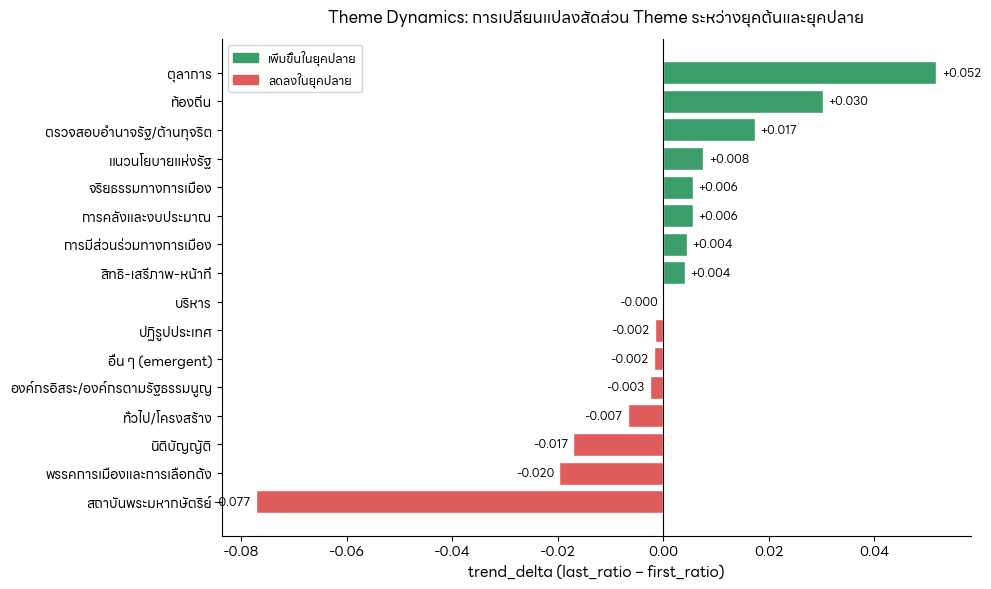

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))

df_dyn = dynamic_df.sort_values('trend_delta')
colors = ['#E05C5C' if x < 0 else '#3B9E6A' for x in df_dyn['trend_delta']]

bars = ax.barh(df_dyn['theme'], df_dyn['trend_delta'], color=colors, edgecolor='white')

for bar, val in zip(bars, df_dyn['trend_delta']):
    offset = 0.001 if val >= 0 else -0.001
    ha = 'left' if val >= 0 else 'right'
    label = f'+{val:.3f}' if val >= 0 else f'{val:.3f}'
    ax.text(val + offset, bar.get_y() + bar.get_height()/2,
            label, va='center', ha=ha, fontsize=8.5)

ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('trend_delta (last_ratio − first_ratio)', fontsize=11)
ax.set_title('Theme Dynamics: การเปลี่ยนแปลงสัดส่วน Theme ระหว่างยุคต้นและยุคปลาย',
             fontsize=12, pad=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

increase_patch = mpatches.Patch(color='#3B9E6A', label='เพิ่มขึ้นในยุคปลาย')
decrease_patch = mpatches.Patch(color='#E05C5C', label='ลดลงในยุคปลาย')
ax.legend(handles=[increase_patch, decrease_patch], fontsize=9)

plt.tight_layout()
# plt.savefig('theme_dynamics_bar.png', dpi=150, bbox_inches='tight')
plt.show()

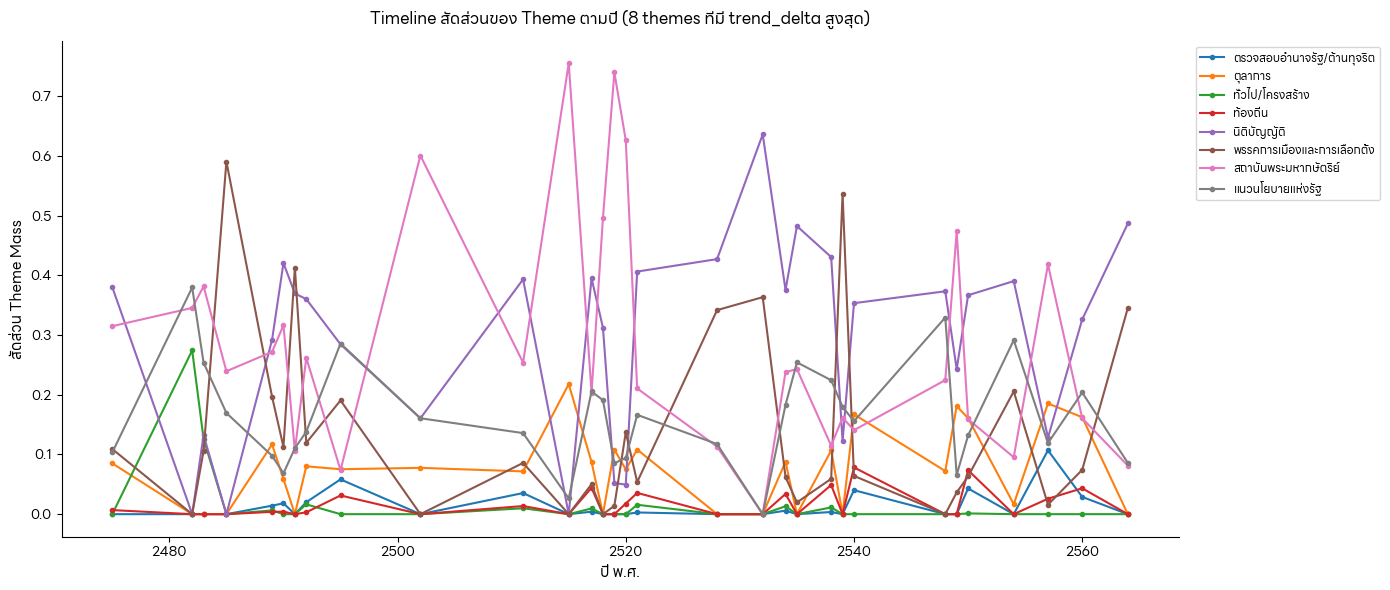

In [8]:
# Timeline — สัดส่วน theme mass ตามปี (เฉพาะ 8 themes หลัก)
TOP_THEMES = (
    dynamic_df.assign(abs_delta=dynamic_df['trend_delta'].abs())
    .nlargest(8, 'abs_delta')['theme'].tolist()
)

tl = timeline_df[timeline_df['theme'].isin(TOP_THEMES)].copy()
tl_pivot = tl.pivot_table(index='year_th', columns='theme', values='theme_score', fill_value=0)
tl_norm = tl_pivot.div(tl_pivot.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(14, 6))
for col in tl_norm.columns:
    ax.plot(tl_norm.index, tl_norm[col], marker='o', markersize=3, linewidth=1.5, label=col)

ax.set_xlabel('ปี พ.ศ.', fontsize=11)
ax.set_ylabel('สัดส่วน Theme Mass', fontsize=11)
ax.set_title('Timeline สัดส่วนของ Theme ตามปี (8 themes ที่มี trend_delta สูงสุด)', fontsize=12, pad=12)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
# plt.savefig('theme_timeline.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5.4.4 Co-occurrence ระหว่าง Theme

จำนวนมาตราที่มีทั้งสอง Theme พร้อมกัน (จาก `conflict_edges.csv`)

In [9]:
# ตาราง 17 — Co-occurrence
cooc_display = edges_df.sort_values('weight', ascending=False).copy()
cooc_display.columns = ['Theme A', 'Theme B', 'จำนวนมาตรา']
cooc_display = cooc_display.reset_index(drop=True)
cooc_display.index += 1
cooc_display

,Theme A,Theme B,จำนวนมาตรา
1,นิติบัญญัติ,สถาบันพระมหากษัตริย์,117
2,นิติบัญญัติ,บริหาร,97
3,นิติบัญญัติ,พรรคการเมืองและการเลือกตั้ง,94
4,สิทธิ-เสรีภาพ-หน้าที่,แนวนโยบายแห่งรัฐ,91
5,บริหาร,สถาบันพระมหากษัตริย์,42
6,ตุลาการ,สิทธิ-เสรีภาพ-หน้าที่,36
7,สถาบันพระมหากษัตริย์,แนวนโยบายแห่งรัฐ,34
8,นิติบัญญัติ,แนวนโยบายแห่งรัฐ,32
9,ตุลาการ,นิติบัญญัติ,25
10,ตุลาการ,สถาบันพระมหากษัตริย์,24


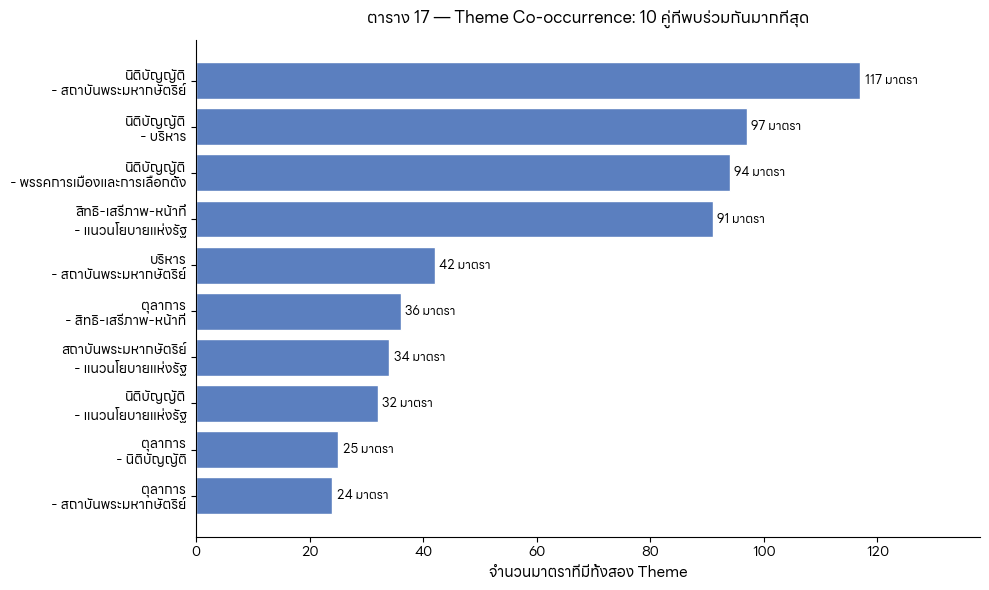

In [10]:
# Co-occurrence bar chart (top 10)
top_edges = edges_df.sort_values('weight', ascending=False).head(10).copy()
top_edges['pair'] = top_edges['source_theme'] + '\n- ' + top_edges['target_theme']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_edges['pair'][::-1], top_edges['weight'][::-1],
               color='#5B7FBF', edgecolor='white')

for bar in bars:
    ax.text(bar.get_width() + 0.8, bar.get_y() + bar.get_height()/2,
            f'{int(bar.get_width())} มาตรา', va='center', fontsize=9)

ax.set_xlabel('จำนวนมาตราที่มีทั้งสอง Theme', fontsize=11)
ax.set_title('ตาราง 17 — Theme Co-occurrence: 10 คู่ที่พบร่วมกันมากที่สุด', fontsize=12, pad=12)
ax.set_xlim(0, top_edges['weight'].max() * 1.18)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
# plt.savefig('theme_cooccurrence_bar.png', dpi=150, bbox_inches='tight')
plt.show()

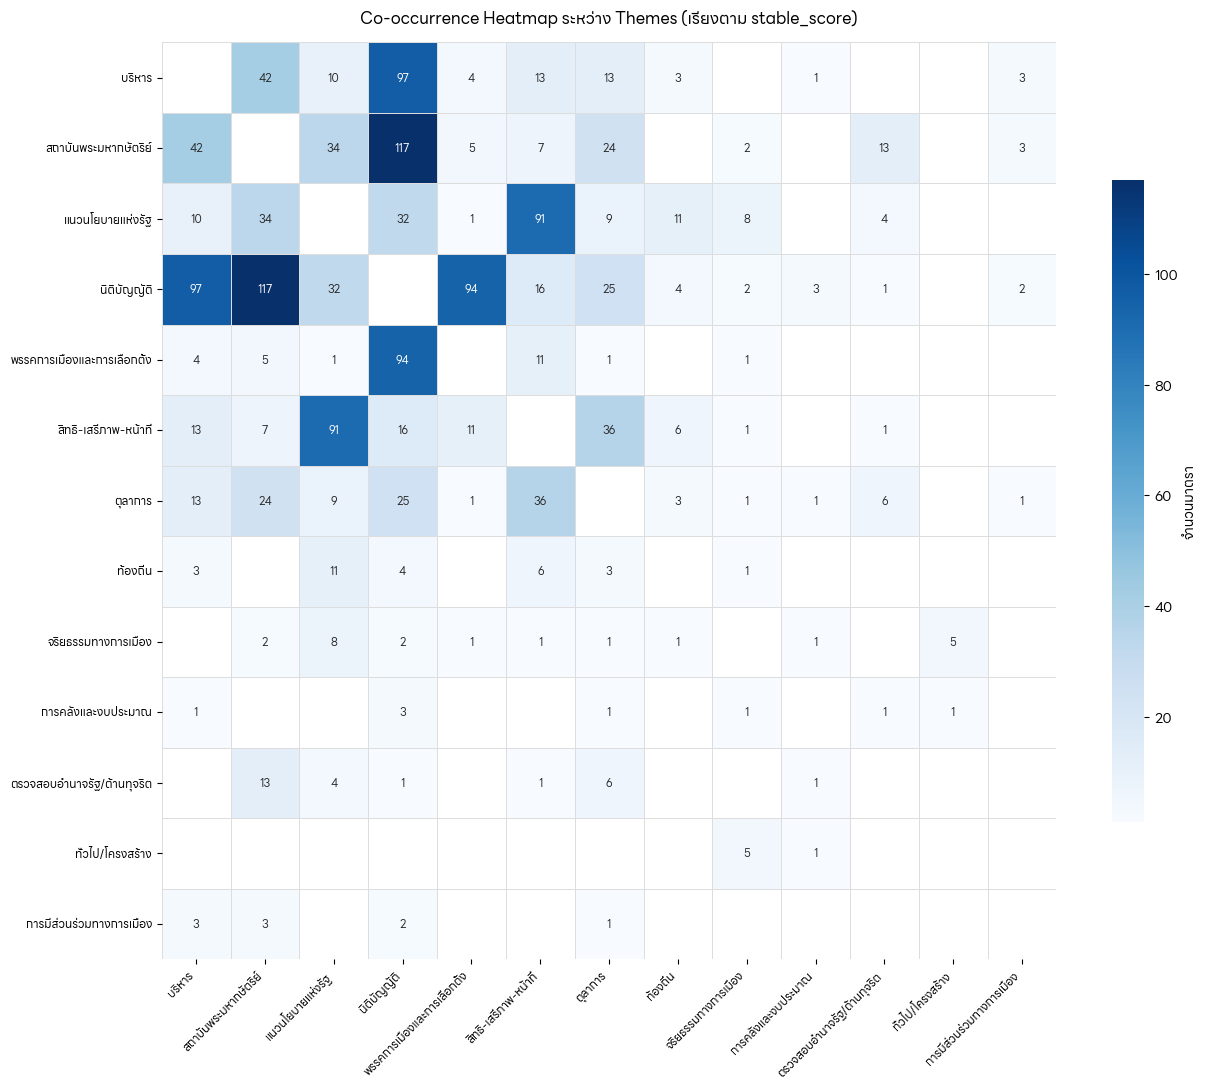

In [11]:
# Co-occurrence heatmap
all_themes = pd.concat([edges_df['source_theme'], edges_df['target_theme']]).unique()
cooc_matrix = pd.DataFrame(0, index=all_themes, columns=all_themes)
for _, row in edges_df.iterrows():
    cooc_matrix.loc[row['source_theme'], row['target_theme']] = row['weight']
    cooc_matrix.loc[row['target_theme'], row['source_theme']] = row['weight']

# เรียง themes ตาม stable_score
theme_order = stable_df.sort_values('stable_score', ascending=False)['theme'].tolist()
theme_order = [t for t in theme_order if t in cooc_matrix.index]
cooc_matrix = cooc_matrix.loc[theme_order, theme_order]

fig, ax = plt.subplots(figsize=(13, 11))
mask = cooc_matrix == 0
sns.heatmap(
    cooc_matrix, annot=True, fmt='d', cmap='Blues',
    linewidths=0.4, linecolor='#ddd',
    mask=mask, ax=ax,
    annot_kws={'size': 8},
    cbar_kws={'shrink': 0.7, 'label': 'จำนวนมาตรา'}
)
ax.set_title('Co-occurrence Heatmap ระหว่าง Themes (เรียงตาม stable_score)', fontsize=12, pad=14)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8.5)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8.5)
plt.tight_layout()
# plt.savefig('theme_cooccurrence_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Summary

ตารางสรุปข้อมูลสำคัญทั้งหมดของ section 5.4

In [12]:
print('=== Theme Stability (top 5) ===')
print(stable_df.sort_values('stable_score', ascending=False)
      [['theme','n_sections','n_constitutions','stable_score']].head(5).to_string(index=False))

print('\n=== Theme Dynamics (biggest shifts) ===')
dyn_sorted = dynamic_df.sort_values('trend_delta')
print('  ลดลงมากที่สุด:')
print(dyn_sorted.head(3)[['theme','first_ratio','last_ratio','trend_delta']].to_string(index=False))
print('  เพิ่มขึ้นมากที่สุด:')
print(dyn_sorted.tail(3)[['theme','first_ratio','last_ratio','trend_delta']].to_string(index=False))

print('\n=== Co-occurrence (top 5 pairs) ===')
print(edges_df.sort_values('weight', ascending=False).head(5).to_string(index=False))

=== Theme Stability (top 5) ===
                      theme  n_sections  n_constitutions  stable_score
                     บริหาร         730               38      0.839327
       สถาบันพระมหากษัตริย์         741               36      0.838303
           แนวนโยบายแห่งรัฐ         612               36      0.820471
                นิติบัญญัติ        1257               33      0.779044
พรรคการเมืองและการเลือกตั้ง         428               28      0.627730

=== Theme Dynamics (biggest shifts) ===
  ลดลงมากที่สุด:
                      theme  first_ratio  last_ratio  trend_delta
       สถาบันพระมหากษัตริย์     0.197435    0.120264    -0.077171
พรรคการเมืองและการเลือกตั้ง     0.068563    0.048841    -0.019722
                นิติบัญญัติ     0.261979    0.244913    -0.017066
  เพิ่มขึ้นมากที่สุด:
                     theme  first_ratio  last_ratio  trend_delta
ตรวจสอบอำนาจรัฐ/ต้านทุจริต     0.010307    0.027621     0.017314
                  ท้องถิ่น     0.014361    0.044575     0.030214
   